Generating aspect raster...
0...10...20...30...40...50...60...70...80...90...100 - done.
Reading aspect raster...

Files created:
- data/aspect_sample.tif
- data/aspect_sample_points.csv

Raster validation:
CRS: EPSG:4326
Bounds: BoundingBox(left=144.6998611111111, bottom=-38.100138888888885, right=145.30013888888888, top=-37.49986111111111)
Shape: (2161, 2161)
Min aspect: 0.0
Max aspect: 359.54886

Sample rows:
144.70027777777776 -37.500277777777775 270.0
145.14083333333332 -37.504999999999995 71.56504821777344
144.97249999999997 -37.51 172.56858825683594
144.81305555555554 -37.515 63.4349479675293
145.25499999999997 -37.51972222222222 156.34579467773438


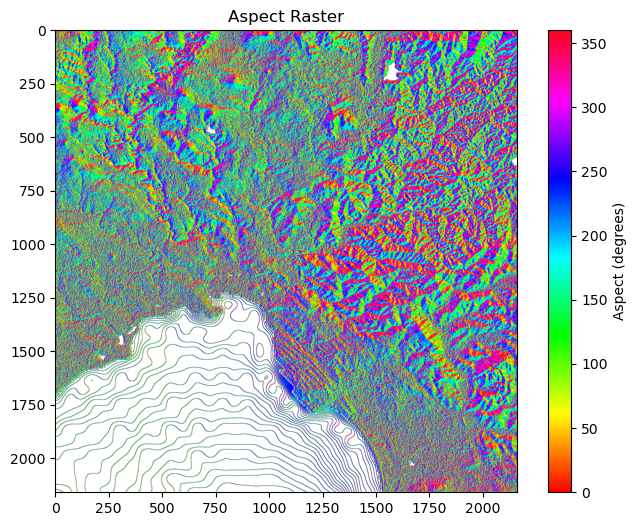

In [1]:
import csv
import shutil
import subprocess
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.transform import xy

data_dir = Path("data")
dem_file = data_dir / "dem_sample.tif"
aspect_file = data_dir / "aspect_sample.tif"
csv_file = data_dir / "aspect_sample_points.csv"

if not dem_file.exists():
    raise FileNotFoundError(f"DEM file not found: {dem_file}")

if shutil.which("gdaldem") is None:
    raise RuntimeError("gdaldem command not found. Install GDAL first.")

print("Generating aspect raster...")
subprocess.run(
    ["gdaldem", "aspect", str(dem_file), str(aspect_file), "-of", "GTiff"],
    check=True
)

print("Reading aspect raster...")
with rasterio.open(aspect_file) as src:
    arr = src.read(1).astype("float32")
    nodata = src.nodata
    crs = src.crs
    raster_bounds = src.bounds
    shape = arr.shape
    transform = src.transform

    if nodata is not None:
        arr[arr == nodata] = np.nan

rows, cols = np.where(~np.isnan(arr))

if len(rows) == 0:
    raise ValueError("No valid aspect values found in the raster.")

sample_n = min(100, len(rows))
idx = np.linspace(0, len(rows) - 1, sample_n, dtype=int)

sample_rows = rows[idx]
sample_cols = cols[idx]

xs, ys = xy(transform, sample_rows, sample_cols)
vals = arr[sample_rows, sample_cols]

with open(csv_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["longitude", "latitude", "aspect_deg"])
    for x, y, v in zip(xs, ys, vals):
        writer.writerow([x, y, float(v)])

print("\nFiles created:")
print(f"- {aspect_file}")
print(f"- {csv_file}")

print("\nRaster validation:")
print("CRS:", crs)
print("Bounds:", raster_bounds)
print("Shape:", shape)
print("Min aspect:", np.nanmin(arr))
print("Max aspect:", np.nanmax(arr))

print("\nSample rows:")
for i in range(min(5, len(vals))):
    print(xs[i], ys[i], float(vals[i]))

plt.figure(figsize=(8, 6))
plt.imshow(arr, cmap="hsv", vmin=0, vmax=360)
plt.colorbar(label="Aspect (degrees)")
plt.title("Aspect Raster")
plt.show()